# Using embeddings to rank 

In [6]:
import pandas as pd
import json 
from pathlib import Path

In [7]:
users = {u["user_id"]: [f["name"] for f in u["folders"]]
         for u in json.load(open("../data/users.json"))["users"]}
labels = pd.read_csv("../data/labels.csv")
transcripts = {p.stem: p.read_text(encoding="utf-8")
               for p in sorted(Path("../data/transcripts_hybrid").glob("*.txt"))}

print(users)
print(len(transcripts), "transcripts")
labels.head()

{'user_a': ['Sports', 'Data Science', 'Career', 'Funny'], 'user_b': ['Volleyball Technique', 'Tennis Technique', 'Pro Highlights', 'Data Science Interviews', 'ML Projects', 'Comedy', 'Things to Send Sarah'], 'user_c': ['Good Stuff', 'Try Later', 'Inspo', 'lol', 'Work']}
14 transcripts


,video_id,user_id,correct_folder,also_relevant
0,reel_001,user_a,Sports,NaN
1,reel_001,user_b,Volleyball Technique,NaN
2,reel_001,user_c,Try Later,NaN
3,reel_002,user_a,Sports,NaN
4,reel_002,user_b,Pro Highlights,Volleyball Technique


## List of reels to remember with no informative transcript (no speech in reel)
## 4, 6, 12, 13

In [14]:
videos = pd.read_csv("../data/videos.csv").set_index("video_id")

no_speech = videos[videos["speech"] == 0]
for reel, row in no_speech.iterrows():
    print(f"{reel}  [{row['topic']}]  {row['description']}")
    print(f"    transcript: {transcripts[reel][:100]!r}\n")

reel_004  [volleyball]  Slow motion volleyball spike
    transcript: "Who does know what's happening in the morning? Call me up there."

reel_006  [data science]  Machine Learning project question
    transcript: 'For this life I cannot change In the hills'

reel_012  [tennis]  Roger Federer slow motion serve
    transcript: 'Thanks for watching! Like, comment, and subscribe for more videos!'

reel_013  [volleyball]  Humorous volleyball skit
    transcript: 'Thank you for watching! Please subscribe and hit the like button!'



## Load sentence embedder and check for token limits

In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="mps")
print("max tokens:", model.max_seq_length)

for reel, text in transcripts.items():
    n_tokens = len(model.tokenizer(text)["input_ids"])
    flag = "TRUNCATED" if n_tokens > model.max_seq_length else ""
    print(f"{reel}  {len(text.split()):4d} words  {n_tokens:4d} tokens  {flag}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (456 > 256). Running this sequence through the model will result in indexing errors


max tokens: 256
reel_001   102 words   119 tokens  
reel_002    59 words    79 tokens  
reel_003   399 words   456 tokens  TRUNCATED
reel_004    12 words    18 tokens  
reel_005   418 words   500 tokens  TRUNCATED
reel_006     9 words    11 tokens  
reel_007   157 words   200 tokens  
reel_008    24 words    27 tokens  
reel_009    91 words   115 tokens  
reel_010    55 words    83 tokens  
reel_011   136 words   180 tokens  
reel_012    10 words    17 tokens  
reel_013    11 words    16 tokens  
reel_014   181 words   238 tokens  


#### Some reels are too long, however the first 256 tokens might still be enough to get a useful semantic representation of the reel.

Another option is to take the average embedding of each section of a long reel. Test and compare performance.

### Compute the embeddings

In [9]:
import numpy as np

# reel embeddings
reel_ids = list(transcripts)                       # fixed order: row i ↔ reel_ids[i]
transcript_emb = model.encode([transcripts[r] for r in reel_ids],
                              normalize_embeddings=True)

# folder name embeddings
folder_emb = {user: model.encode(folders, normalize_embeddings=True)
              for user, folders in users.items()}

print("transcripts:", transcript_emb.shape)
for user, emb in folder_emb.items():
    print(user, emb.shape)
print("vector lengths:", np.linalg.norm(transcript_emb, axis=1).round(3))

transcripts: (14, 384)
user_a (4, 384)
user_b (7, 384)
user_c (5, 384)
vector lengths: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Sanity check on embeddings

In [12]:
def sim(a, b):
    return float(transcript_emb[reel_ids.index(a)] @ transcript_emb[reel_ids.index(b)]) # @ = dot product = cosine sim (because normalized)

print("volleyball vs volleyball (reel_001, reel_003):", round(sim("reel_001", "reel_003"), 3))
print("volleyball vs data science (reel_001, reel_005):", round(sim("reel_001", "reel_005"), 3))


volleyball vs volleyball (reel_001, reel_003): 0.35
volleyball vs data science (reel_001, reel_005): 0.054


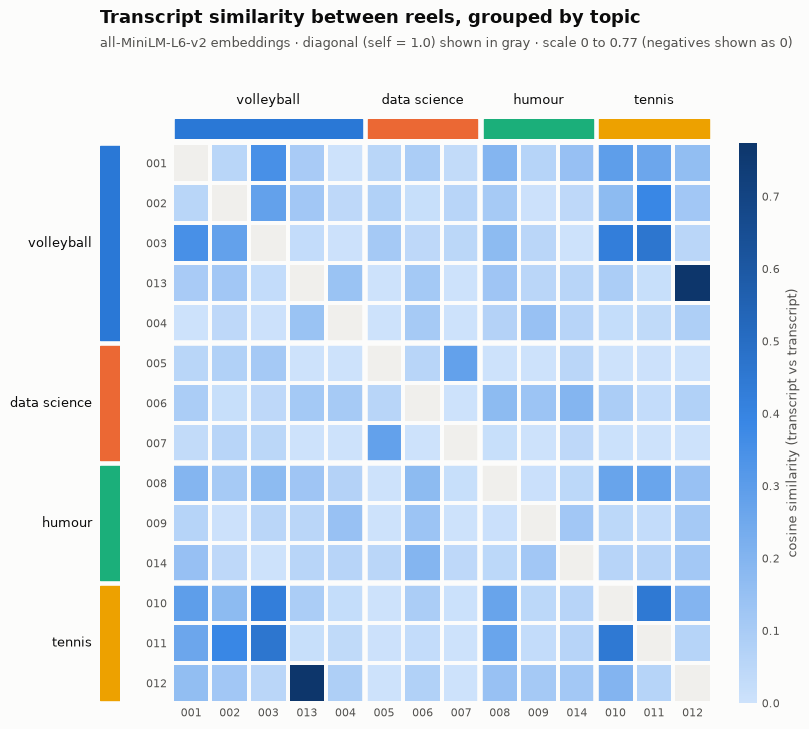

,reel_001,reel_002,reel_003,reel_013,reel_004,reel_005,reel_006,reel_007,reel_008,reel_009,reel_014,reel_010,reel_011,reel_012
reel_001,1.00,0.05,0.35,0.10,-0.03,0.05,0.10,0.03,0.20,0.06,0.15,0.30,0.26,0.16
reel_002,0.05,1.00,0.28,0.12,0.04,0.08,0.02,0.06,0.11,0.01,0.04,0.17,0.39,0.12
reel_003,0.35,0.28,1.00,0.03,0.01,0.11,0.04,0.05,0.17,0.05,-0.02,0.42,0.46,0.05
reel_013,0.10,0.12,0.03,1.00,0.14,-0.08,0.11,-0.12,0.13,0.05,0.06,0.09,0.02,0.77
reel_004,-0.03,0.04,0.01,0.14,1.00,-0.07,0.11,-0.01,0.07,0.15,0.06,0.02,0.04,0.09
reel_005,0.05,0.08,0.11,-0.08,-0.07,1.00,0.06,0.28,-0.03,-0.03,0.05,-0.06,0.00,-0.06
reel_006,0.10,0.02,0.04,0.11,0.11,0.06,1.00,-0.07,0.17,0.14,0.20,0.10,0.03,0.08
reel_007,0.03,0.06,0.05,-0.12,-0.01,0.28,-0.07,1.00,0.02,-0.09,0.04,0.01,-0.05,-0.07
reel_008,0.20,0.11,0.17,0.13,0.07,-0.03,0.17,0.02,1.00,0.01,0.05,0.27,0.27,0.15
reel_009,0.06,0.01,0.05,0.05,0.15,-0.03,0.14,-0.09,0.01,1.00,0.12,0.05,0.03,0.11


In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

videos = pd.read_csv("../data/videos.csv").set_index("video_id")

# order reels by topic (in the order topics first appear), then by id
topics = list(dict.fromkeys(videos.loc[reel_ids, "topic"]))
order = [r for t in topics for r in reel_ids if videos.loc[r, "topic"] == t]
order.remove("reel_013")
order.insert(order.index("reel_003") + 1, "reel_013")

# all pairwise dot products (= cosine similarity, since vectors are normalized)
idx = [reel_ids.index(r) for r in order]
sim = transcript_emb[idx] @ transcript_emb[idx].T
sim_df = pd.DataFrame(sim, index=order, columns=order)

# colors: one sequential blue ramp for similarity, fixed categorical slots for topics
seq = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
cmap = LinearSegmentedColormap.from_list("blue", seq)
cmap.set_bad("#f0efec")                       # diagonal (self-similarity) in neutral gray
topic_colors = dict(zip(topics, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
surface, ink, ink2 = "#fcfcfb", "#0b0b0b", "#52514e"

plot = np.ma.masked_where(np.eye(len(order), dtype=bool), sim)   # hide the diagonal of 1s
vmax = plot.max()

n = len(order)
fig = plt.figure(figsize=(9, 8), facecolor=surface)
ax = fig.add_axes([0.22, 0.08, 0.60, 0.70])
mesh = ax.pcolormesh(plot, cmap=cmap, vmin=0, vmax=vmax,
                     edgecolors=surface, linewidth=1.5)       # thin gap between cells
ax.set_xlim(0, n); ax.set_ylim(n, 0); ax.set_facecolor(surface)
ax.set_xticks(np.arange(n) + 0.5, [r[-3:] for r in order], fontsize=8, color=ink2)
ax.set_yticks(np.arange(n) + 0.5, [r[-3:] for r in order], fontsize=8, color=ink2)
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)

# thicker separators between topic groups
bounds = [i for i in range(1, n) if videos.loc[order[i], "topic"] != videos.loc[order[i-1], "topic"]]
for b in bounds:
    ax.axhline(b, color=surface, lw=4); ax.axvline(b, color=surface, lw=4)

# topic strips on the left and top, each labeled with its name
strip_l = fig.add_axes([0.14, 0.08, 0.022, 0.70], sharey=ax)
strip_t = fig.add_axes([0.22, 0.785, 0.60, 0.025], sharex=ax)
starts = [0] + bounds; ends = bounds + [n]
for s, e in zip(starts, ends):
    t = videos.loc[order[s], "topic"]; c = topic_colors[t]
    strip_l.add_patch(plt.Rectangle((0, s + 0.08), 1, e - s - 0.16, color=c))
    strip_t.add_patch(plt.Rectangle((s + 0.08, 0), e - s - 0.16, 1, color=c))
    strip_l.text(-0.4, (s + e) / 2, t, ha="right", va="center", fontsize=9, color=ink)
    strip_t.text((s + e) / 2, 1.6, t, ha="center", va="bottom", fontsize=9, color=ink)
for a in (strip_l, strip_t):
    a.set_axis_off()
strip_l.set_xlim(0, 1); strip_t.set_ylim(0, 1)

cax = fig.add_axes([0.85, 0.08, 0.02, 0.70])
cb = fig.colorbar(mesh, cax=cax)
cb.set_label("cosine similarity (transcript vs transcript)", color=ink2, fontsize=9)
cb.outline.set_visible(False); cb.ax.tick_params(colors=ink2, labelsize=8, length=0)

fig.text(0.14, 0.93, "Transcript similarity between reels, grouped by topic",
         fontsize=13, color=ink, weight="bold")
fig.text(0.14, 0.90, f"all-MiniLM-L6-v2 embeddings · diagonal (self = 1.0) shown in gray · scale 0 to {vmax:.2f} (negatives shown as 0)",
         fontsize=9, color=ink2)
plt.show()

sim_df.round(2)          # table view of the same numbers


### What I learn from the plot  
- Reels 12 and 13 are both stock phrases - the high similarity makes sense
- Reel 3 (volleyball) is more similar to 10 and 11 (tennis) than the other volleyball reels
- Data science 5 and 7 is quite strong (do not interpret reel 6 - no speech video), and do not align strongly with other categories
- Humour is really hard to cluster with transcripts of different funny reels

## Ranking time

#### Test Reel 1 (volleyball) on user b

In [15]:
reel, user = "reel_001", "user_b"

reel_vec = transcript_emb[reel_ids.index(reel)]       # shape (384,)
scores = folder_emb[user] @ reel_vec                  # one score per folder, shape (7,) because user_b has 7 folders

ranking = sorted(zip(users[user], scores), key=lambda x: x[1], reverse=True)
for rank, (folder, score) in enumerate(ranking, start=1):
    print(f"{rank}. {folder:25s} {score:.3f}")

print("\ncorrect:", labels.query("video_id == @reel and user_id == @user")["correct_folder"].item())

1. Volleyball Technique      0.282
2. Tennis Technique          0.200
3. Pro Highlights            0.143
4. ML Projects               0.062
5. Data Science Interviews   0.025
6. Things to Send Sarah      0.010
7. Comedy                    -0.035

correct: Volleyball Technique


In [25]:
reel, user = "reel_011", "user_a"

reel_vec = transcript_emb[reel_ids.index(reel)]       # shape (384,)
scores = folder_emb[user] @ reel_vec                  # one score per folder, shape (7,) because user_b has 7 folders

ranking = sorted(zip(users[user], scores), key=lambda x: x[1], reverse=True)
for rank, (folder, score) in enumerate(ranking, start=1):
    print(f"{rank}. {folder:25s} {score:.3f}")

print("\ncorrect:", labels.query("video_id == @reel and user_id == @user")["correct_folder"].item())

1. Sports                    0.211
2. Career                    0.077
3. Funny                     0.071
4. Data Science              -0.073

correct: Sports


In [22]:
def rank_folders(transcript, folders, model):
    """Rank a user's folders by how similar each folder name is to the transcript.

    Returns a list of (folder, score) pairs, best match first.
    """
    reel_vec = model.encode(transcript, normalize_embeddings=True)       # (384,)
    folder_vecs = model.encode(folders, normalize_embeddings=True)       # (n_folders, 384)
    scores = folder_vecs @ reel_vec                                      # cosine similarity per folder
    ranking = sorted(zip(folders, scores.tolist()), key=lambda x: x[1], reverse=True)
    return ranking

In [23]:
rows = []
for _, lab in labels.iterrows():
    ranking = rank_folders(transcripts[lab.video_id], users[lab.user_id], model)
    for rank, (folder, score) in enumerate(ranking, start=1):
        rows.append({"video_id": lab.video_id, "user_id": lab.user_id,
                     "folder": folder, "score": score, "rank": rank,
                     "is_correct": folder == lab.correct_folder})
rankings = pd.DataFrame(rows)

correct_rank = rankings[rankings.is_correct].set_index(["video_id", "user_id"])["rank"]
correct_rank.unstack("user_id")


user_id,user_a,user_b,user_c
video_id,,,
reel_001,1,1,1
reel_002,1,3,4
reel_003,1,1,1
reel_004,2,6,5
reel_005,2,1,4
reel_006,3,2,4
reel_007,2,1,2
reel_008,3,7,4
reel_009,1,1,2


User C has very ambiguous folder names (good stuff, try later) so the bad rankings make sense.

In [24]:
rankings

,video_id,user_id,folder,score,rank,is_correct
0,reel_001,user_a,Sports,0.082013,1,True
1,reel_001,user_a,Career,0.067239,2,False
2,reel_001,user_a,Data Science,-0.021095,3,False
3,reel_001,user_a,Funny,-0.038885,4,False
4,reel_001,user_b,Volleyball Technique,0.281887,1,True
...,...,...,...,...,...,...
219,reel_014,user_c,Good Stuff,0.125142,1,False
220,reel_014,user_c,Work,0.114959,2,False
221,reel_014,user_c,lol,0.076844,3,True
222,reel_014,user_c,Try Later,0.067440,4,False
